Выполним импорты нужных библиотек

In [64]:
import numpy as np
import dtreeviz
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import r2_score, roc_auc_score, roc_curve, auc

from tqdm import tqdm

In [46]:
!pip install -q tqdm

Зафиксируем случайности и размер тестовой выборки

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.25 

Загрузим датасет для предсказания стоимости домов в Калифорнии

In [4]:
data = fetch_california_housing(as_frame = True)

X = data.data
y = data.target

In [36]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [4]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Разобьем данные на трейн и тест

In [5]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

Обучим дерево на трейне и оценим качество на тесте

In [8]:
model = DecisionTreeRegressor()

model.fit(Xtrain, ytrain)

pred = model.predict(Xtest)

r2_dt_test = r2_score(ytest, pred)

print(f'r2 on test is {r2_dt_test}')

r2 on test is 0.5990534028163258


In [10]:
pred_train = model.predict(Xtrain)

r2_dt_train = r2_score(ytrain, pred_train)

print(f'r2 on train is {r2_dt_train}')

r2 on train is 1.0


Дерево сильно переобучилось

Попробуем ограничить дерево по глубине

Decision Tree with depth 1 gives r2 = 0.32 on train and r2 = 0.29 on test. Diff is 0.02
Decision Tree with depth 2 gives r2 = 0.45 on train and r2 = 0.43 on test. Diff is 0.02
Decision Tree with depth 3 gives r2 = 0.54 on train and r2 = 0.52 on test. Diff is 0.02
Decision Tree with depth 4 gives r2 = 0.59 on train and r2 = 0.57 on test. Diff is 0.02
Decision Tree with depth 5 gives r2 = 0.63 on train and r2 = 0.6 on test. Diff is 0.03
Decision Tree with depth 6 gives r2 = 0.67 on train and r2 = 0.63 on test. Diff is 0.04
Decision Tree with depth 7 gives r2 = 0.71 on train and r2 = 0.65 on test. Diff is 0.06
Decision Tree with depth 8 gives r2 = 0.76 on train and r2 = 0.68 on test. Diff is 0.08
Decision Tree with depth 9 gives r2 = 0.8 on train and r2 = 0.69 on test. Diff is 0.11
Decision Tree with depth 10 gives r2 = 0.83 on train and r2 = 0.69 on test. Diff is 0.14
Decision Tree with depth 11 gives r2 = 0.87 on train and r2 = 0.68 on test. Diff is 0.19
Decision Tree with depth 12 give

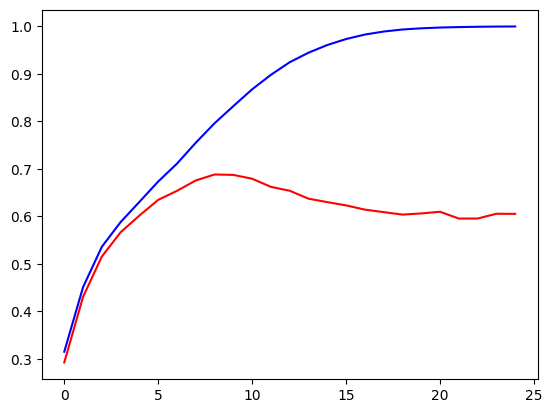

In [18]:
train_scores = []
test_scores = []

for depth in np.arange(1, 26, 1):
    model = DecisionTreeRegressor(max_depth=depth)

    model.fit(Xtrain, ytrain)
    
    pred_train = model.predict(Xtrain)
    pred_test = model.predict(Xtest)
    
    r2_dt_train = r2_score(ytrain, pred_train)
    r2_dt_test = r2_score(ytest, pred_test)

    train_scores.append(r2_dt_train)
    test_scores.append(r2_dt_test)
    
    print(f'Decision Tree with depth {depth} gives r2 = {round(r2_dt_train, 2)} on train and r2 = {round(r2_dt_test, 2)} on test. Diff is {round(r2_dt_train - r2_dt_test, 2)}')

plt.plot(train_scores, color = 'blue')
plt.plot(test_scores, color = 'red')
plt.show()

Судя по результатам эксперимента, оптимальная глубина дерева `max_depth = 8`.
Но мы узнали это по конкретному разбиению на трейн и тест, чтобы не привязываться к конкретному разбиению, 
можно посмотреть качество модели по кросс-валидации

In [25]:
model = DecisionTreeRegressor(max_depth = 8)

cv_DT = cross_val_score(model, X, y, cv = 3, scoring = 'r2')

cv_DT.mean()

np.float64(0.5145772329432453)

Решающее дерево можно визуализировать

Это очень удобно для интерпретации результатов

In [28]:
model = DecisionTreeRegressor(max_depth=3)
model.fit(Xtrain, ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [35]:
viz_model = dtreeviz.model(model, Xtrain, ytrain, feature_names=Xtrain.columns)

viz_model.view(fancy = False, scale=2)

C:\Users\1\anaconda3\envs\new_env_name\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names


## Подберем гиперпараметры дерева по кросс-валидации по сетке при помощи GridSearchCV

In [5]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
params = {'max_depth': np.arange(2, 10),
          'min_samples_split' : np.arange(2, 10, 2),
          'min_samples_leaf': np.arange(1, 10, 2)}

gs = GridSearchCV(DecisionTreeRegressor(), params, cv = 3, scoring = 'r2', verbose = 2)

gs.fit(X, y)

Fitting 3 folds for each of 160 candidates, totalling 480 fits
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=4; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=6; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=6; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=6; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=8; total time=   0.0s
[CV] END max_depth=2, min_samples_leaf=1, min_samples_split=8; total time=   0.0s
[CV] END max_depth=2, min_samples_l

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': array([2, 3, ..., 6, 7, 8, 9]), 'min_samples_leaf': array([1, 3, 5, 7, 9]), 'min_samples_split': array([2, 4, 6, 8])}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [7]:
gs.best_estimator_, gs.best_score_

(DecisionTreeRegressor(max_depth=np.int64(5), min_samples_leaf=np.int64(9),
                       min_samples_split=np.int64(2)),
 np.float64(0.539089224323314))

Используем прунинг для уменьшения количества вершин в дереве и, следовательно, для снижения переобучения.

Прунинг при обучении дерева использует регуляризованный функционал
$$Q_{\alpha}(T) = Q(T) + \alpha |T|,$$
где $T$ - дерево, $Q(T)$ - функция потерь, $|T|$ - число вершин в дереве.

В sklearn есть Cost-Complexity pruning, который возвращает список возможных порогов $\alpha$ при построении дерева  
(т.к. данных конечное число, то не нужно рассматривать бесконечное число значений).

In [8]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

tree = DecisionTreeRegressor()

path = tree.cost_complexity_pruning_path(Xtrain, ytrain)
alphas = path['ccp_alphas'] # Получаем массив из всех возможных значений альфа, которые стоит рассмотреть, чтобы получить все возможные архитектуры дерева

alphas

array([0.00000000e+00, 5.73758669e-20, 5.73758669e-20, ...,
       7.95140486e-02, 1.01733053e-01, 4.20802794e-01], shape=(13916,))

Чем больше $\alpha$, тем сильнее регуляризация, и тем меньше дерево переобучается.

Посмотрим на зависимость качества предсказания дерева на тренировочных и тестовых данных в зависимости от $\alpha$.

TQDM

Некоторые операции в python выполняются долго.
* Иногда прямо внутри функции есть параметр `verbose`, настроив который, можно узнать сколько уже итераций сделано.
* Если мы хотим посмотреть, как долго будет выполняться цикл, нам поможет библиотека `tqdm`

In [9]:
for i in tqdm(range(10000000)):
    pass

100%|█████████████████████████████████████████████████████████████████| 10000000/10000000 [00:02<00:00, 4769962.65it/s]


In [10]:
cv_score = []

for i in tqdm(alphas[::100]):
    tree = DecisionTreeRegressor()

    cv_tree = cross_val_score(tree, X, y, cv = 3, scoring = 'r2').mean()
    cv_score.append(cv_tree)

100%|████████████████████████████████████████████████████████████████████████████████| 140/140 [01:00<00:00,  2.32it/s]


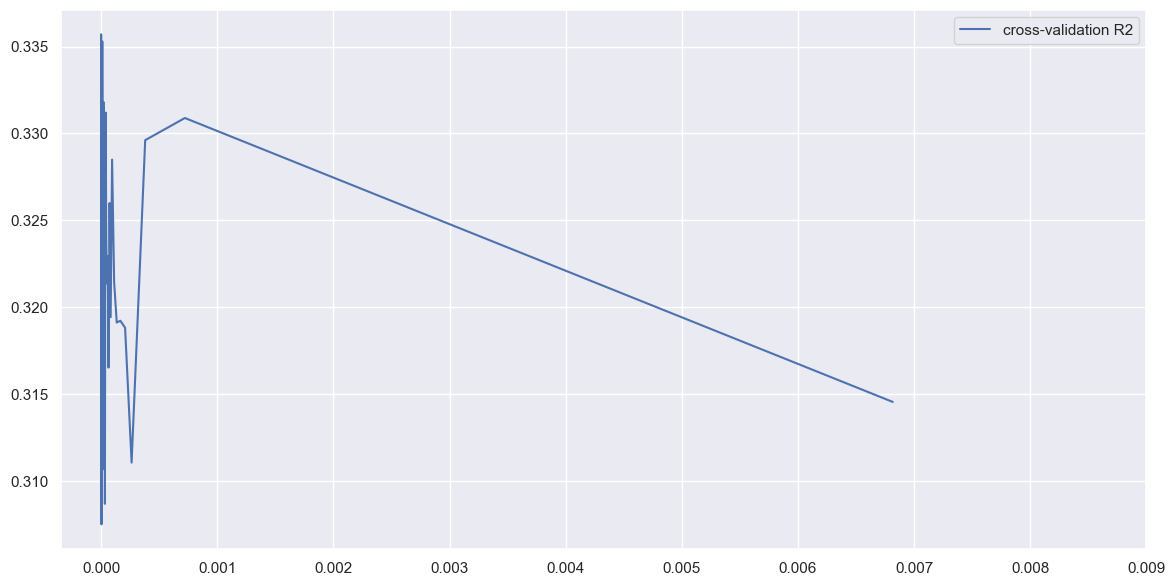

In [11]:
sns.set()
plt.figure(figsize=(14,7))
sns.lineplot(y = cv_score, x = alphas[::100], label = "cross-validation R2")
plt.xticks(ticks = np.arange(0.00,0.01,0.001))
plt.show()

# Будем решать задачу оттока: для клиентов телекома предсказывать, кто останется в компании, а кто уйдет

## Импорт библиотек и загрузка данных

In [1]:
!python --version

Python 3.9.25


In [2]:
%%capture 
!python -m pip install --upgrade pip
!pip install --upgrade scikit-learn-intelex

In [2]:
from sklearnex import patch_sklearn 
patch_sklearn()

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [3]:
import sys
import os
import site
import pandas as pd
import numpy as np

sys.path.append(os.path.join(os.path.dirname(site.getsitepackages()[0]), "site-packages"))

In [4]:
# зафиксируем константы
RANDOM_STATE = 42

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/telecom_churn.csv")
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [6]:
df.describe(include = 'object')

,State,International plan,Voice mail plan
count,3333,3333,3333
unique,51,2,2
top,WV,No,No
freq,106,3010,2411


In [7]:
df['Churn'].unique()

array([False,  True])

## Практика

In [8]:
np.random.seed(RANDOM_STATE)

Сделайте первичную обработку данных:

1) Выбросите колонку State

2) Колонки International plan и Voice mail plan закодируйте следующим образом: "Yes" замените на 1, а "No" на 0.

3) Переведите целевую переменную (Churn) в числа: True в 1, а False в 0.

In [9]:
df = df.drop('State', axis = 1)

In [10]:
df['International plan'] = df['International plan'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Voice mail plan'] = df['Voice mail plan'].apply(lambda x: 1 if x == 'Yes' else 0)

In [11]:
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == True else 0)

### Вопрос

Чему равна сумма значений в закодированном столбце International plan?

In [12]:
df['International plan'].sum()

np.int64(323)

Выведите на экран первые строки измененной таблицы, чтобы проверить, что все преобразования сработали.

In [13]:
df.head()

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


Создайте матрицу объект-признак X и вектор с целевой переменной (Churn) y.

In [14]:
X = df.drop('Churn', axis = 1)
y = df['Churn']

Масштабируем данные

In [15]:
ss = StandardScaler()

ss.fit(X)

X = pd.DataFrame(ss.transform(X), columns = X.columns)

In [16]:
X

,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
0,0.676489,-0.523603,-0.327580,1.617086,1.234883,1.566767,0.476643,1.567036,-0.070610,-0.055940,-0.070427,0.866743,-0.465494,0.866029,-0.085008,-0.601195,-0.085690,-0.427932
1,0.149065,-0.523603,-0.327580,1.617086,1.307948,-0.333738,1.124503,-0.334013,-0.108080,0.144867,-0.107549,1.058571,0.147825,1.059390,1.240482,-0.601195,1.241169,-0.427932
2,0.902529,-0.523603,-0.327580,-0.618396,-0.591760,1.168304,0.675985,1.168464,-1.573383,0.496279,-1.573900,-0.756869,0.198935,-0.755571,0.703121,0.211534,0.697156,-1.188218
3,-0.428590,-0.688834,3.052685,-0.618396,-0.591760,2.196596,-1.466936,2.196759,-2.742865,-0.608159,-2.743268,-0.078551,-0.567714,-0.078806,-1.303026,1.024263,-1.306401,0.332354
4,-0.654629,-0.523603,3.052685,-0.618396,-0.591760,-0.240090,0.626149,-0.240041,-1.038932,1.098699,-1.037939,-0.276311,1.067803,-0.276562,-0.049184,-0.601195,-0.045885,1.092641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,2.283878,-0.523603,-0.327580,1.617086,2.038605,-0.432895,-1.167924,-0.433386,0.286348,1.299506,0.286880,1.547039,-0.874374,1.547188,-0.120832,0.617898,-0.125496,0.332354
3329,-0.830437,-0.523603,-0.327580,-0.618396,-0.591760,0.942447,-2.164631,0.942714,-0.938353,-2.264816,-0.938172,-0.189297,1.170023,-0.188670,-0.228304,-0.194831,-0.231645,1.092641
3330,-1.835055,1.718817,-0.327580,-0.618396,-0.591760,0.018820,0.426808,0.019193,1.731930,-2.114211,1.732349,-0.177431,-0.465494,-0.175486,1.383778,0.617898,1.387123,0.332354
3331,2.082955,1.718817,3.052685,-0.618396,-0.591760,0.624778,0.227466,0.625153,-0.816080,-0.808966,-0.815203,-1.219628,1.885562,-1.221396,-1.876211,2.243356,-1.876950,0.332354


### Вопрос

Проверьте баланс классов. Является ли выборка сбалансированной?

In [17]:
y.value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

По кросс-валидации с тремя фолдами и метрикой ROC-AUC (scoring='roc_auc') обучите: 

1) Логистическую регрессию

2) Метод опорных векторов (с kernel='linear')

Выведите на экран среднее качество моделей на кросс-валидации.

При объявлении SVC не забудьте указать в гиперпараметрах probability = True (так как метод изначально не предсказывает вероятности классов, а они нам нужны для вычисления ROC-AUC).

In [27]:
logreg = LogisticRegression()
svc = SVC(kernel = 'linear', probability = True)

cv_lr = cross_val_score(logreg, X, y, cv = 3, scoring = 'roc_auc')
cv_svc = cross_val_score(svc, X, y, cv = 3, scoring = 'roc_auc')

Теперь обучите решающее дерево с параметрами по умолчанию по кросс-валидации с тремя фолдами и той же метрикой.

ВАЖНО! У решающего дерева для воспроизводимости результатов фиксируйте random_state = RANDOM_STATE

In [28]:
tree = DecisionTreeClassifier(random_state = RANDOM_STATE)

cv_tree = cross_val_score(tree, X, y, cv = 3, scoring = 'roc_auc')

### Вопрос

Какой из трех алгоритмов показал наилучшее качество на кросс-валидации?

In [29]:
print(f'ROC-AUC score of LogReg is {round(cv_lr.mean(), 5)}\nROC-AUC score of SVC is {round(cv_svc.mean(), 5)}\nROC-AUC score of Tree is {round(cv_tree.mean(), 5)}')

ROC-AUC score of LogReg is 0.81416
ROC-AUC score of SVC is 0.6982
ROC-AUC score of Tree is 0.83562


In [33]:
np.arange(0.1, 10, 0.5)

array([0.1, 0.6, 1.1, 1.6, 2.1, 2.6, 3.1, 3.6, 4.1, 4.6, 5.1, 5.6, 6.1,
       6.6, 7.1, 7.6, 8.1, 8.6, 9.1, 9.6])

In [34]:
np.linspace(0.1, 10.01, 20)

array([ 0.1       ,  0.62157895,  1.14315789,  1.66473684,  2.18631579,
        2.70789474,  3.22947368,  3.75105263,  4.27263158,  4.79421053,
        5.31578947,  5.83736842,  6.35894737,  6.88052632,  7.40210526,
        7.92368421,  8.44526316,  8.96684211,  9.48842105, 10.01      ])

Ваша цель - максимально улучшить модели. Для этого:

1) у линейных моделей подберите гиперпараметр С (переберите 20 значений C в диапазоне от 0.1 до 10 с равным шагом).

2) у решающего дерева подберите max_depth (переберите глубину от 1 до 10 с шагом 1) и criterion - "gini" или "entropy".

Для подбора параметров используйте GridSearchCV с тремя фолдами и метрикой roc-auc или обычные циклы.

Подбор параметров осуществляется только по тренировочным данным!

При подборе гиперпараметров по кросс-валидации для дальнейшей корректной оценки качества модели нужна отдельная выборка. Давайте сразу действовать правильно:

1) сначала разбиваем (как и раньше) данные на тренировочную и тестовую части
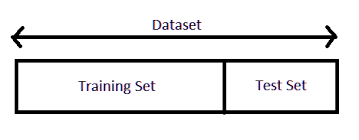

2) затем по тренировочной части при помощи GridSearchCV подбираем оптимальные значения гиперпараметров

3) наконец, делаем предсказание модели с оптимальными гиперпараметрами на тестовых данных и уже по ним оцениваем итоговую метрику.

Сложно, зато правильно!

In [47]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.7, random_state=RANDOM_STATE)

In [57]:
params = {'C' : np.linspace(0.1, 10.01, 20)} # тут используем linspace, а не arange, т к знаем не шаг, а кол-во значений

gs = GridSearchCV(LogisticRegression(), params, cv = 3, scoring = 'roc_auc')
gs.fit(Xtrain, ytrain)

gs_best_score_logreg = gs.best_score_
gs_best_params_logreg = gs.best_params_

best_lr = gs.best_estimator_

pred_lr = best_lr.predict_proba(Xtest)[:,1]

roc_auc_lr = roc_auc_score(ytest, pred_lr)

print(f'ROC_AUC of best LogReg on test is {round(roc_auc_lr, 4)}')

ROC_AUC of best LogReg on test is 0.8285


In [58]:
params = {'C' : np.linspace(0.1, 10.01, 20)} # тут используем linspace, а не arange, т к знаем не шаг, а кол-во значений

gs = GridSearchCV(SVC(kernel = 'linear', probability = True), params, cv = 3, scoring = 'roc_auc')
gs.fit(Xtrain, ytrain)

gs_best_score_svc = gs.best_score_
gs_best_params_svc = gs.best_params_

best_svc = gs.best_estimator_

pred_svc = best_svc.predict_proba(Xtest)[:,1]

roc_auc_svc = roc_auc_score(ytest, pred_svc)

print(f'ROC_AUC of best SVC on test is {round(roc_auc_svc, 4)}')

ROC_AUC of best SVC on test is 0.7228


C:\Users\1\anaconda3\envs\py39\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names


In [59]:
params = {'max_depth' : np.arange(1, 10, 1), 'criterion': ['gini', 'entropy']} # тут используем arange, т к знаем шаг

gs = GridSearchCV(DecisionTreeClassifier(random_state = 42), params, cv = 3, scoring = 'roc_auc')
gs.fit(Xtrain, ytrain)

gs_best_score_tree = gs.best_score_
gs_best_params_tree = gs.best_params_

best_tree = gs.best_estimator_

pred_tree = best_tree.predict_proba(Xtest)[:,1]

roc_auc_tree = roc_auc_score(ytest, pred_tree)

print(f'ROC_AUC of best Tree on test is {round(roc_auc_tree, 4)}')

ROC_AUC of best Tree on test is 0.8556


### Вопрос

Чему равно качество решающего дерева с подобранными гиперпараметрами, посчитанное на тестовой выборке?

Ответ округлите до сотых.

In [66]:
print(f'ROC_AUC of best Tree on test is {round(roc_auc_tree, 2)}')

ROC_AUC of best Tree on test is 0.86


Нарисуйте roc-кривую для наилучшей модели.

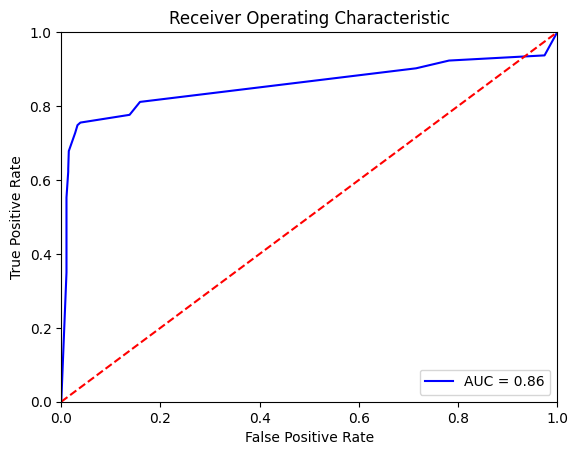

In [65]:
# Построим ROC-кривую

fpr, tpr, threshold = roc_curve(ytest, pred_tree)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()



Сравните между собой две лучшие модели.

Насколько сильно отличается качество предсказания на тестовых данных? (вычислите разность значений roc-auc)
Ответ округлите до сотых.


In [69]:
print(f'Diff of ROC_AUC`s of 2 best models on test is {round(roc_auc_tree - roc_auc_lr, 2)}')

Diff of ROC_AUC`s of 2 best models on test is 0.03




Постройте гистограммы важности признаков (для линейных моделей берите модуль значений весов) для каждой из этих моделей. Сравните между собой списки из трех самых важных признаков. Совпадают ли они?


C:\Users\1\AppData\Local\Temp\ipykernel_6552\472069415.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



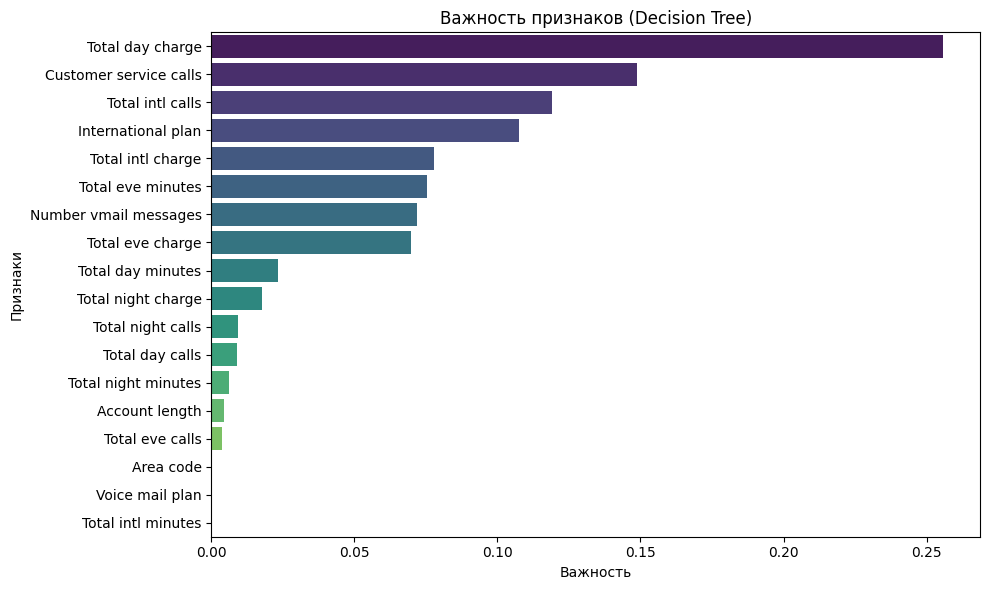

In [70]:
# Предположим, у вас есть список названий признаков
feature_names = Xtrain.columns  # если Xtrain — DataFrame

# Извлекаем важности из обученной модели дерева
tree_importances = best_tree.feature_importances_

# Создаём DataFrame для удобства сортировки и визуализации
tree_imp_df = pd.DataFrame({'feature': feature_names, 'importance': tree_importances})
tree_imp_df = tree_imp_df.sort_values('importance', ascending=False)

# Строим горизонтальную гистограмму (столбцовую диаграмму)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=tree_imp_df, palette='viridis')
plt.title('Важность признаков (Decision Tree)')
plt.xlabel('Важность')
plt.ylabel('Признаки')
plt.tight_layout()
plt.show()